In [1]:
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import seaborn as sns
import os
import glob
from datetime import datetime
from datetime import timedelta
from matplotlib import pyplot as plt
import matplotlib.dates as md
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
from matplotlib import cm
import matplotlib.dates as mdates
from scipy.interpolate import interp2d
warnings.filterwarnings('ignore')
#import datetime
import scipy.ndimage as ndimage
from matplotlib import cm
import geopy.distance
#import matplotlib as mpl
from scipy.interpolate import interp1d
from sklearn.linear_model import LinearRegression
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame
import leafmap
import plotly.express as px
import matplotlib as mpl
import xarray as xr
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
import math
#import pysplit
import netCDF4
import xarray as xr
import matplotlib.ticker as mticker

In [2]:
# Set the folder path where your CSVs are located
'''folder_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI'

# Use glob to match all CSV files
csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

# Read and combine them into a single DataFrame
all_data = pd.concat([pd.read_csv(file) for file in csv_files], ignore_index=True)

all_data'''


"folder_path = 'C:/Users/taiwoajayi/\\OneDrive - University of Arizona/Arizona_ozone/NEI'\n\n# Use glob to match all CSV files\ncsv_files = glob.glob(os.path.join(folder_path, '*.csv'))\n\n# Read and combine them into a single DataFrame\nall_data = pd.concat([pd.read_csv(file) for file in csv_files], ignore_index=True)\n\nall_data"

In [3]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/Biogenic/Biogenic2008.xlsx'

# Read the CSV file into a pandas DataFrame
Bio8 = pd.read_excel(csv_file_path, skiprows=0)
Bio8

,State Name,County Name,FIPS,CO,NO,ALD2,ALDX,ETH,ETHA,ETOH,FORM,IOLE,ISOP,MEOH,NR,OLE,PAR,TERP,VOC,SESQ
0,Alabama,Autauga Co,1001,2.111895e+03,2.072329e+02,220.948628,54.679930,317.081530,76.843571,5.209150e+02,301.301022,8.029020e+02,8.497227e+03,1.071004e+03,4.016348e+02,4.556077e+02,1.620785e+03,4.372217e+03,1.871315e+04,377.417661
1,Alabama,Baldwin Co,1003,5.609732e+03,6.434817e+02,587.065833,145.286150,842.085800,203.297900,1.383411e+03,800.560040,2.133333e+03,1.599200e+04,2.784266e+03,1.063576e+03,1.808664e+03,5.270793e+03,1.088108e+04,4.389542e+04,775.709039
2,Alabama,Barbour Co,1005,2.855592e+03,1.978462e+02,298.732426,73.929259,428.762622,104.010590,7.043889e+02,407.369021,1.085559e+03,1.386012e+04,1.360878e+03,5.434939e+02,5.433205e+02,2.099155e+03,5.805946e+03,2.731566e+04,442.685730
3,Alabama,Bibb Co,1007,2.335138e+03,6.745481e+01,244.177154,60.428540,350.720350,85.569879,5.761774e+02,332.977847,8.873156e+02,1.189570e+04,1.127268e+03,4.464836e+02,6.037448e+02,1.928910e+03,6.102166e+03,2.464164e+04,458.789112
4,Alabama,Blount Co,1009,1.903148e+03,1.571662e+02,199.012260,49.250414,285.831590,69.708876,4.695754e+02,271.384878,7.231876e+02,8.850191e+03,9.164604e+02,3.637680e+02,3.395841e+02,1.359612e+03,3.692284e+03,1.758985e+04,311.768564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3105,Wyoming,Teton Co,56039,4.809526e+03,1.206205e+02,503.437863,124.590243,721.854885,173.753154,1.185892e+03,686.519166,1.829436e+03,2.148698e+04,1.375026e+03,9.096896e+02,1.032408e+03,3.754780e+03,7.965470e+03,4.174983e+04,244.969101
3106,Wyoming,Uinta Co,56041,2.513366e+03,2.441266e+02,263.279246,65.155445,377.135140,89.882354,6.195722e+02,359.024054,9.567256e+02,2.295761e+03,1.377164e+03,4.717347e+02,7.346337e+02,2.255466e+03,2.565087e+03,1.243062e+04,137.250973
3107,Wyoming,Washakie Co,56043,3.411792e+03,2.828366e+02,357.412030,88.451117,511.870455,121.911143,8.409221e+02,487.388525,1.298796e+03,1.531742e+03,1.903110e+03,6.399548e+02,1.075462e+03,3.178727e+03,3.656860e+03,1.569261e+04,213.512280
3108,Wyoming,Weston Co,56045,3.450336e+03,2.537991e+02,361.458104,89.452258,517.575641,123.251038,8.502956e+02,492.905545,1.313493e+03,1.927502e+03,2.028105e+03,6.470377e+02,2.031338e+03,4.630468e+03,4.485891e+03,1.949877e+04,197.467390


In [4]:
Bio8 = Bio8[Bio8['County Name'] == 'Pima Co']
Bio8


,State Name,County Name,FIPS,CO,NO,ALD2,ALDX,ETH,ETHA,ETOH,FORM,IOLE,ISOP,MEOH,NR,OLE,PAR,TERP,VOC,SESQ
77,Arizona,Pima Co,4019,40278.1185,1607.3901,4217.62743,1043.76598,6043.8722,1447.92682,9929.1064,5751.4089,15326.3749,32144.69498,27235.30302,7589.6917,7517.4219,29762.5683,36291.0825,184300.84503,4355.54397


In [5]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/Biogenic/Biogenic2011.xlsx'

# Read the CSV file into a pandas DataFrame
Bio11 = pd.read_excel(csv_file_path, skiprows=0)
Bio11

,region_cd,state,county,sector,poll,ann_value,jan_value,feb_value,mar_value,apr_value,may_value,jun_value,jul_value,aug_value,sep_value,oct_value,nov_value,dec_value
0,1001,Alabama,Autauga Co,beis,CO,2717.605600,44.812900,86.799400,143.88200,210.9606,274.9646,430.8180,408.1743,459.5560,276.6377,172.1245,117.8747,91.00090
1,1001,Alabama,Autauga Co,beis,NOX,160.332000,6.467000,7.428400,10.03860,21.8766,15.8403,19.5024,20.1995,17.3647,13.9844,10.8615,8.8785,7.89010
2,1001,Alabama,Autauga Co,beis,VOC_INV,23620.713400,262.174000,572.740400,1027.57600,1834.1650,2631.2750,4313.9620,3868.1000,4399.7000,2259.4170,1240.7900,708.9260,501.88800
3,1003,Alabama,Baldwin Co,beis,CO,8074.937600,183.137800,271.945100,467.14640,640.3300,789.0540,1213.6710,1134.6870,1260.2600,835.6820,554.5920,404.0912,320.34110
4,1003,Alabama,Baldwin Co,beis,NOX,427.922700,17.979200,18.904300,26.57570,58.9140,50.2003,48.7839,50.7803,45.1969,36.1366,28.4400,24.2096,21.80190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9322,56043,Wyoming,Washakie Co,beis,NOX,468.071514,9.510250,6.572534,25.92420,34.4634,44.4675,58.6033,81.8123,78.9858,58.9826,43.5039,18.1377,7.10803
9323,56043,Wyoming,Washakie Co,beis,VOC_INV,13960.227800,104.729100,90.450000,211.30120,283.9877,788.0098,1945.7790,4027.1390,3584.6370,1857.2420,821.5376,142.5397,102.87570
9324,56045,Wyoming,Weston Co,beis,CO,3496.723800,32.219900,29.498100,58.53240,80.8125,211.6602,496.1456,934.4970,861.4760,470.1802,236.9489,49.5058,35.24720
9325,56045,Wyoming,Weston Co,beis,NOX,680.728036,16.012491,12.497935,34.76886,48.1404,61.2645,85.6322,118.3641,113.3925,82.5831,62.3148,29.8401,15.91705


In [6]:
Bio11 = Bio11[Bio11['county'] == 'Pima Co']
Bio11


,region_cd,state,county,sector,poll,ann_value,jan_value,feb_value,mar_value,apr_value,may_value,jun_value,jul_value,aug_value,sep_value,oct_value,nov_value,dec_value
231,4019,Arizona,Pima Co,beis,CO,40681.2834,667.468,1054.1494,2102.9990,2717.4510,3461.9660,6113.8100,6333.100,6640.6100,5510.0900,3611.4770,1597.6850,870.478
232,4019,Arizona,Pima Co,beis,NOX,770.5797,40.718,36.9102,54.9974,63.5208,69.3612,83.1954,90.697,92.4643,83.4636,70.6059,47.2989,37.347
233,4019,Arizona,Pima Co,beis,VOC_INV,184876.8060,2458.992,4029.5790,9171.4800,12766.8800,17308.3200,30242.1000,29923.510,30005.9500,24647.7100,15344.2400,5944.1900,3033.855


In [7]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/Biogenic/Biogenic2014.xlsx'

# Read the CSV file into a pandas DataFrame
Bio14 = pd.read_excel(csv_file_path, skiprows=0)
Bio14

,region_cd,state,county,sector,poll,ann_value,jan_value,feb_value,mar_value,apr_value,may_value,jun_value,jul_value,aug_value,sep_value,oct_value,nov_value,dec_value
0,1001,Alabama,Autauga Co,beis,CO,2457.666800,39.212000,54.806300,114.576000,178.1213,275.5115,350.7424,374.0026,399.6928,322.5384,207.8938,75.043200,65.52650
1,1001,Alabama,Autauga Co,beis,NOX,157.377170,5.637770,6.762000,8.745100,22.4240,18.7497,17.6079,17.8378,17.3667,14.8997,11.9447,7.438400,7.96340
2,1001,Alabama,Autauga Co,beis,VOC_INV,21332.481800,229.298200,329.560700,796.575700,1443.3890,2648.2940,3379.6980,3631.2780,3780.4970,2710.4730,1544.3600,454.276700,384.78150
3,1003,Alabama,Baldwin Co,beis,CO,7275.866000,156.330100,255.964900,345.588100,511.0552,754.2250,986.2310,1038.6290,1128.7840,921.3430,638.7120,280.895300,258.10840
4,1003,Alabama,Baldwin Co,beis,NOX,398.833900,16.478600,18.455300,22.548600,43.9994,52.1471,44.2699,46.8847,42.8152,37.4567,31.1673,20.648300,21.96280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9322,56043,Wyoming,Washakie Co,beis,NOX,469.174981,9.157116,6.509083,24.115186,35.6117,52.6942,58.2819,79.0097,70.6611,55.3777,44.4988,18.127205,15.13129
9323,56043,Wyoming,Washakie Co,beis,VOC_INV,13270.812500,111.365900,90.636300,213.953500,365.2469,1388.4975,1986.6000,3902.2570,2726.7580,1507.0430,677.6072,164.279900,136.56730
9324,56045,Wyoming,Weston Co,beis,CO,3214.834600,38.104300,27.987700,66.109300,103.5325,309.6550,474.3339,832.6330,704.4910,398.7668,162.5103,52.976300,43.73450
9325,56045,Wyoming,Weston Co,beis,NOX,698.776627,21.624250,12.203957,38.092200,52.7995,73.5906,84.1701,112.8692,107.4930,82.2155,63.3627,27.310100,23.04552


In [8]:
Bio14 = Bio14[Bio14['county'] == 'Pima Co']
Bio14


,region_cd,state,county,sector,poll,ann_value,jan_value,feb_value,mar_value,apr_value,may_value,jun_value,jul_value,aug_value,sep_value,oct_value,nov_value,dec_value
231,4019,Arizona,Pima Co,beis,CO,42913.7030,1601.7580,1703.8100,2202.2900,2806.0650,4252.7250,6670.0300,6319.7400,5596.7900,4911.5000,3695.6920,1856.8860,1296.417
232,4019,Arizona,Pima Co,beis,NOX,795.3469,45.6589,45.7079,55.7554,63.2134,74.4074,85.7021,90.6691,87.2394,80.8788,72.3277,50.7398,43.047
233,4019,Arizona,Pima Co,beis,VOC_INV,194918.4670,6026.5300,6992.7800,9718.2900,13397.1700,21301.1900,32777.4000,29460.8300,25890.9400,21721.8300,15983.2500,7111.6100,4536.647


In [9]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/Biogenic/Biogenic2017.xlsx'

# Read the CSV file into a pandas DataFrame
Bio17 = pd.read_excel(csv_file_path, skiprows=0)
Bio17

,region_cd,state,county,poll,ann_value,jan_value,feb_value,mar_value,apr_value,may_value,jun_value,jul_value,aug_value,sep_value,oct_value,nov_value,dec_value
0,1001,Alabama,Autauga Co,CO,1399.7478,53.7216,59.8069,81.2971,119.0991,141.4859,161.9798,216.9938,198.4106,155.4004,117.4600,64.5247,29.5679
1,1003,Alabama,Baldwin Co,CO,4895.4377,222.5369,230.9900,299.9046,385.1717,485.2052,545.4860,688.4640,659.6840,533.4540,426.8411,247.7077,169.9925
2,1005,Alabama,Barbour Co,CO,2229.4481,88.0765,98.7991,131.4396,186.1057,226.8250,250.5581,327.1020,306.6794,241.6107,188.2423,106.2950,77.7147
3,1007,Alabama,Bibb Co,CO,2108.9700,78.4581,83.6809,118.9406,180.8099,214.5180,248.5345,334.3977,299.4195,232.2601,173.8236,96.4545,47.6726
4,1009,Alabama,Blount Co,CO,1158.7519,19.8827,19.5269,52.3592,107.8199,127.8517,151.8970,196.8700,174.5835,130.6091,99.1802,56.6806,21.4911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9319,56037,Wyoming,Sweetwater Co,VOC,14568.5526,76.4029,132.1033,268.2098,304.1789,1004.2122,2833.7690,4269.8510,3166.3070,1853.5790,331.8540,203.0262,125.0593
9320,56039,Wyoming,Teton Co,VOC,22383.7845,199.3140,308.1407,561.2997,622.9060,1589.8310,3384.3610,6963.7200,4838.1640,2594.7500,664.4240,397.0325,259.8416
9321,56041,Wyoming,Uinta Co,VOC,3908.2287,30.2589,44.3948,82.2815,87.2118,284.9368,743.7160,1081.4070,858.4320,472.6214,108.2401,70.6564,44.0720
9322,56043,Wyoming,Washakie Co,VOC,4050.5508,22.4572,39.5409,80.5130,110.5550,388.6824,687.5850,1210.4380,838.1240,483.1179,110.3392,48.4683,30.7299


In [10]:
Bio17 = Bio17[Bio17['county'] == 'Pima Co']
Bio17


,region_cd,state,county,poll,ann_value,jan_value,feb_value,mar_value,apr_value,may_value,jun_value,jul_value,aug_value,sep_value,oct_value,nov_value,dec_value
77,4019,Arizona,Pima Co,CO,17135.5589,441.3244,554.8670,1004.6800,1147.2180,1527.8400,2671.5870,2423.4840,2446.9770,1855.5150,1519.2990,957.1270,585.6405
3185,4019,Arizona,Pima Co,NOX,783.3233,39.5962,41.7028,58.6145,62.1967,70.9153,84.3315,86.3745,86.7815,77.6152,72.5947,57.4977,45.1027
6293,4019,Arizona,Pima Co,VOC,76225.9810,1548.3640,2114.7610,4420.1150,5386.3170,7444.1160,12494.2400,11076.6300,11186.6800,8277.6000,6498.5100,3698.6740,2079.9740


In [11]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/Biogenic/Biogenic2020.xlsx'

# Read the CSV file into a pandas DataFrame
Bio20 = pd.read_excel(csv_file_path, skiprows=0)
Bio20

,state,fips state code,tribal name,fips code,county,sector,reporting period,emissions operating type,pollutant code,pollutant desc,total emissions,emissions uom,data set
0,NY,36,NaN,36059,Nassau,Biogenics - Vegetation and Soil,A,R,CO,Carbon Monoxide,182.06390,TON,2020NEI
1,WI,55,NaN,55137,Waushara,Biogenics - Vegetation and Soil,A,R,NOX,Nitrogen Oxides,324.14410,TON,2020NEI
2,CA,6,NaN,6027,Inyo,Biogenics - Vegetation and Soil,A,R,CO,Carbon Monoxide,3272.77300,TON,2020NEI
3,VA,51,NaN,51081,Greensville,Biogenics - Vegetation and Soil,A,R,CO,Carbon Monoxide,546.66700,TON,2020NEI
4,RI,44,NaN,44009,Washington,Biogenics - Vegetation and Soil,A,R,NOX,Nitrogen Oxides,46.42084,TON,2020NEI
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9667,KS,20,NaN,20065,Graham,Biogenics - Vegetation and Soil,A,R,CO,Carbon Monoxide,614.48680,TON,2020NEI
9668,WI,55,NaN,55063,La Crosse,Biogenics - Vegetation and Soil,A,R,CO,Carbon Monoxide,528.81810,TON,2020NEI
9669,PA,42,NaN,42051,Fayette,Biogenics - Vegetation and Soil,A,R,NOX,Nitrogen Oxides,240.52440,TON,2020NEI
9670,PA,42,NaN,42043,Dauphin,Biogenics - Vegetation and Soil,A,R,VOC,Volatile Organic Compounds,9185.27300,TON,2020NEI


In [12]:
Bio20 = Bio20[Bio20['county'] == 'Pima']
Bio20


,state,fips state code,tribal name,fips code,county,sector,reporting period,emissions operating type,pollutant code,pollutant desc,total emissions,emissions uom,data set
1768,AZ,4,NaN,4019,Pima,Biogenics - Vegetation and Soil,A,R,NOX,Nitrogen Oxides,706.9467,TON,2020NEI
5095,AZ,4,NaN,4019,Pima,Biogenics - Vegetation and Soil,A,R,VOC,Volatile Organic Compounds,25166.2000,TON,2020NEI
8725,AZ,4,NaN,4019,Pima,Biogenics - Vegetation and Soil,A,R,CO,Carbon Monoxide,4700.8510,TON,2020NEI


In [13]:
# Initialize lists for pollutant records
records_CO = []
records_NOx = []
records_VOC = []

# -------- Bio08 (wide format) --------
bio08 = Bio8.copy()
records_CO.append({'year': 2008, 'value': bio08['CO'].iloc[0]})
records_NOx.append({'year': 2008, 'value': bio08['NO'].iloc[0]})  # Assuming NO as proxy for NOx
records_VOC.append({'year': 2008, 'value': bio08['VOC'].iloc[0]})

# -------- Bio11 (long format) --------
bio11 = Bio11.copy()
bio11_CO = bio11[bio11['poll'] == 'CO']
bio11_NOx = bio11[bio11['poll'] == 'NOX']
bio11_VOC = bio11[bio11['poll'].str.contains('VOC', case=False)]

records_CO.append({'year': 2011, 'value': bio11_CO['ann_value'].values[0]})
records_NOx.append({'year': 2011, 'value': bio11_NOx['ann_value'].values[0]})
records_VOC.append({'year': 2011, 'value': bio11_VOC['ann_value'].values[0]})

# -------- Bio14 --------
bio14 = Bio14.copy()
records_CO.append({'year': 2014, 'value': bio14[bio14['poll'] == 'CO']['ann_value'].values[0]})
records_NOx.append({'year': 2014, 'value': bio14[bio14['poll'] == 'NOX']['ann_value'].values[0]})
records_VOC.append({'year': 2014, 'value': bio14[bio14['poll'].str.contains('VOC', case=False)]['ann_value'].values[0]})

# -------- Bio17 --------
bio17 = Bio17.copy()
records_CO.append({'year': 2017, 'value': bio17[bio17['poll'] == 'CO']['ann_value'].values[0]})
records_NOx.append({'year': 2017, 'value': bio17[bio17['poll'] == 'NOX']['ann_value'].values[0]})
records_VOC.append({'year': 2017, 'value': bio17[bio17['poll'] == 'VOC']['ann_value'].values[0]})

# -------- Bio20 --------
bio20 = Bio20.copy()
records_CO.append({'year': 2020, 'value': bio20[bio20['pollutant code'] == 'CO']['total emissions'].values[0]})
records_NOx.append({'year': 2020, 'value': bio20[bio20['pollutant code'] == 'NOX']['total emissions'].values[0]})
records_VOC.append({'year': 2020, 'value': bio20[bio20['pollutant code'] == 'VOC']['total emissions'].values[0]})

# -------- Create DataFrames --------
Bio_CO = pd.DataFrame(records_CO)
Bio_NOx = pd.DataFrame(records_NOx)
Bio_VOC = pd.DataFrame(records_VOC)


In [14]:
Bio_CO

,year,value
0,2008,40278.1185
1,2011,40681.2834
2,2014,42913.7030
3,2017,17135.5589
4,2020,4700.8510


In [15]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/Fire/fire2011.xlsx'
Fire11 = pd.read_excel(csv_file_path, skiprows=0)
Fire11

,state_and_county_fips_code,st_usps_cd,county_name,scc,SCC_Level_One,SCC_Level_Two,SCC_Level_Three,SCC_Level_Four,EI_Sector,pollutant_cd,description,total_emissions,uom
0,4019,AZ,Pima,2810001000,Miscellaneous Area Sources,Other Combustion,Forest Wildfires,Wildfires,Fires - Wildfires,106423,p-Xylene,5684.698966,LB
1,4019,AZ,Pima,2811015000,Miscellaneous Area Sources,Other Combustion - as Event,Prescribed Forest Burning,Unspecified Burn Method,Fires - Prescribed Fires,106423,p-Xylene,41.972862,LB
2,4019,AZ,Pima,2811015000,Miscellaneous Area Sources,Other Combustion - as Event,Prescribed Forest Burning,Unspecified Burn Method,Fires - Prescribed Fires,106990,"1,3-Butadiene",364.903157,LB
3,4019,AZ,Pima,2810001000,Miscellaneous Area Sources,Other Combustion,Forest Wildfires,Wildfires,Fires - Wildfires,106990,"1,3-Butadiene",49421.473581,LB
4,4019,AZ,Pima,2811015000,Miscellaneous Area Sources,Other Combustion - as Event,Prescribed Forest Burning,Unspecified Burn Method,Fires - Prescribed Fires,107028,Acrolein,382.020274,LB
...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,4019,AZ,Pima,2810001000,Miscellaneous Area Sources,Other Combustion,Forest Wildfires,Wildfires,Fires - Wildfires,PM25-PRI,PM2.5 Primary (Filt + Cond),1236.086435,TON
74,4019,AZ,Pima,2810001000,Miscellaneous Area Sources,Other Combustion,Forest Wildfires,Wildfires,Fires - Wildfires,SO2,Sulfur Dioxide,119.496810,TON
75,4019,AZ,Pima,2811015000,Miscellaneous Area Sources,Other Combustion - as Event,Prescribed Forest Burning,Unspecified Burn Method,Fires - Prescribed Fires,SO2,Sulfur Dioxide,0.882858,TON
76,4019,AZ,Pima,2810001000,Miscellaneous Area Sources,Other Combustion,Forest Wildfires,Wildfires,Fires - Wildfires,VOC,Volatile Organic Compounds,3294.986680,TON


In [16]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/Fire/fire2014.xlsx'
Fire14 = pd.read_excel(csv_file_path, skiprows=0)
Fire14

,fips,state,county,SCC,fire_type,pollutant code,pollutant desc,total emissions,emissions uom
0,4019,AZ,Pima,2810001000,Wildfire,100425,Styrene,2064.586385,LB
1,4019,AZ,Pima,2810001000,Wildfire,106990,"1,3-Butadiene",5399.690784,LB
2,4019,AZ,Pima,2810001000,Wildfire,107028,Acrolein,10164.116410,LB
3,4019,AZ,Pima,2810001000,Wildfire,108883,Toluene,6829.021842,LB
4,4019,AZ,Pima,2810001000,Wildfire,110543,Hexane,952.886828,LB
...,...,...,...,...,...,...,...,...,...
91,4019,AZ,Pima,2811015000,Prescribed Fire,PM25-PRI,PM2.5 Primary (Filt + Cond),63.207329,TON
92,4019,AZ,Pima,2811015000,Prescribed Fire,PMFINE,Remaining PMFINE portion of PM2.5-PRI,23.690099,TON
93,4019,AZ,Pima,2811015000,Prescribed Fire,SO2,Sulfur Dioxide,6.856962,TON
94,4019,AZ,Pima,2811015000,Prescribed Fire,SO4,Sulfate Portion of PM2.5-PRI,0.208584,TON


In [17]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/Fire/fire2017.xlsx'
Fire17 = pd.read_excel(csv_file_path, skiprows=0)
Fire17

,state,fips state code,tribal name,fips code,county,data category,emissions type code,scc,reporting period,emissions operating type,pollutant code,pollutant desc,total emissions,emissions uom,data set
0,AZ,4,NaN,4019,Pima,E,NaN,2810001001,A,R,71432,Benzene,4437.418189,LB,2017NEI_Apr2020
1,AZ,4,NaN,4019,Pima,E,NaN,2810001001,A,R,OC,Organic Carbon portion of PM2.5-PRI,76.778811,TON,2017NEI_Apr2020
2,AZ,4,NaN,4019,Pima,E,NaN,2810001001,A,R,79107,Acrylic Acid,690.265061,LB,2017NEI_Apr2020
3,AZ,4,NaN,4019,Pima,E,NaN,2810001001,A,R,95476,o-Xylene,749.430590,LB,2017NEI_Apr2020
4,AZ,4,NaN,4019,Pima,E,NaN,2810001001,A,R,CO2,Carbon Dioxide,13717.832920,TON,2017NEI_Apr2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,AZ,4,NaN,4019,Pima,E,NaN,2811015002,A,R,74873,Methyl Chloride,864.023407,LB,2017NEI_Apr2020
184,AZ,4,NaN,4019,Pima,E,NaN,2811015002,A,R,CH4,Methane,29.159160,TON,2017NEI_Apr2020
185,AZ,4,NaN,4019,Pima,E,NaN,2811015002,A,R,NH3,Ammonia,9.376255,TON,2017NEI_Apr2020
186,AZ,4,NaN,4019,Pima,E,NaN,2811015002,A,R,NOX,Nitrogen Oxides,15.429827,TON,2017NEI_Apr2020


In [18]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/Fire/fire20202.xlsx'
Fire20 = pd.read_excel(csv_file_path, skiprows=0)
Fire20

,date,id,event_id,event_name,latitude,longitude,type,area,fips,state,...,Acetaldehyde,Acrylic Acid,Phenanthrene,Fluorene,Naphthalene,o-Xylene,Cumene,Nitrobenzene,sources,scc_description
0,20200610,SF11C02663008,SF11E01826885,Unknown,32.299000,-111.887000,WF,39.00,4019,Arizona,...,0.020475,0.000855,0.000061,NaN,0.005937,0.000928,NaN,NaN,hms 2020 wildland and grass,wildfire/flaming
1,20200610,SF11C02663009,SF11E01826885,Unknown,32.324000,-111.901000,WF,39.00,4019,Arizona,...,0.020475,0.000855,0.000061,NaN,0.005937,0.000928,NaN,NaN,hms 2020 wildland and grass,wildfire/flaming
2,20200615,SF11C02663861,SF11E01827431,Big Fields,31.934000,-112.061000,WF,19.87,4019,Arizona,...,0.010278,0.000429,0.000031,NaN,0.002980,0.000466,NaN,NaN,hms 2020 wildland and grass;ics209 2020 conus,wildfire/flaming
3,20200711,SF11C02667054,SF11E01829571,Cimmarron,32.399000,-112.376000,WF,19.87,4019,Arizona,...,0.010432,0.000436,0.000031,NaN,0.003025,0.000473,NaN,NaN,hms 2020 wildland and grass;ics209 2020 conus,wildfire/flaming
4,20200910,SF11C02676387,SF11E01834435,Unknown,31.952000,-111.778000,WF,39.00,4019,Arizona,...,0.020174,0.000843,0.000060,NaN,0.005850,0.000915,NaN,NaN,hms 2020 wildland and grass,wildfire/flaming
5,20200911,SF11C02676388,SF11E01834435,Unknown,31.954000,-111.776000,WF,39.00,4019,Arizona,...,0.020174,0.000843,0.000060,NaN,0.005850,0.000915,NaN,NaN,hms 2020 wildland and grass,wildfire/flaming
6,20201009,SF11C02681585,SF11E01837291,Unknown,31.567000,-111.785000,WF,39.00,4019,Arizona,...,0.000828,0.000035,0.000002,NaN,0.000240,0.000038,NaN,NaN,hms 2020 wildland and grass,wildfire/smoldering
7,20201009,SF11C02681585,SF11E01837291,Unknown,31.567000,-111.785000,WF,39.00,4019,Arizona,...,0.071099,0.002970,0.000212,NaN,0.020617,0.003224,NaN,NaN,hms 2020 wildland and grass,wildfire/flaming
8,20201011,SF11C02789648,SF11E01878077,Encinos,31.670295,-111.646068,WF,578.50,4019,Arizona,...,1.193437,0.049845,0.003556,NaN,0.346068,0.054118,NaN,NaN,hms 2020 wildland and grass;ics209 2020 conus;...,wildfire/flaming
9,20201011,SF11C02789648,SF11E01878077,Encinos,31.670295,-111.646068,WF,578.50,4019,Arizona,...,0.038126,0.001592,0.000114,NaN,0.011056,0.001729,NaN,NaN,hms 2020 wildland and grass;ics209 2020 conus;...,wildfire/smoldering


In [19]:
# Conversion factor
LB_TO_TON = 1 / 2000

# Initialize result containers
fire_co, fire_nox, fire_voc = [], [], []

# --- Fire11 ---
df11 = Fire11.copy()
def extract_fire11(df, pollutant):
    lbs = df[(df['pollutant_cd'] == pollutant) & (df['uom'] == 'LB')]['total_emissions'].sum()
    tons = df[(df['pollutant_cd'] == pollutant) & (df['uom'] == 'TON')]['total_emissions'].sum()
    return lbs * LB_TO_TON + tons

fire_co.append({'year': 2011, 'value': extract_fire11(df11, 'CO')})
fire_nox.append({'year': 2011, 'value': extract_fire11(df11, 'NOX')})
fire_voc.append({'year': 2011, 'value': extract_fire11(df11, 'VOC')})

# --- Fire14 ---
df14 = Fire14.copy()
df14.columns = df14.columns.str.strip()  # ensure clean column names

def extract_fire14(df, pollutant):
    lbs = df[(df['pollutant code'] == pollutant) & (df['emissions uom'] == 'LB')]['total emissions'].sum()
    tons = df[(df['pollutant code'] == pollutant) & (df['emissions uom'] == 'TON')]['total emissions'].sum()
    return lbs * LB_TO_TON + tons

fire_co.append({'year': 2014, 'value': extract_fire14(df14, 'CO')})
fire_nox.append({'year': 2014, 'value': extract_fire14(df14, 'NOX')})
fire_voc.append({'year': 2014, 'value': extract_fire14(df14, 'VOC')})

# --- Fire17 ---
df17 = Fire17.copy()
def extract_fire17(df, pollutant):
    lbs = df[(df['pollutant code'] == pollutant) & (df['emissions uom'] == 'LB')]['total emissions'].sum()
    tons = df[(df['pollutant code'] == pollutant) & (df['emissions uom'] == 'TON')]['total emissions'].sum()
    return lbs * LB_TO_TON + tons

fire_co.append({'year': 2017, 'value': extract_fire17(df17, 'CO')})
fire_nox.append({'year': 2017, 'value': extract_fire17(df17, 'NOX')})
fire_voc.append({'year': 2017, 'value': extract_fire17(df17, 'VOC')})

# --- Fire2020 ---
df20 = Fire20.copy()

# Already in tons
fire_co.append({'year': 2020, 'value': df20['co'].sum()})
fire_nox.append({'year': 2020, 'value': df20['nox'].sum()})
fire_voc.append({'year': 2020, 'value': df20['voc'].sum()})

# --- Final DataFrames ---
df_fire_CO = pd.DataFrame(fire_co)
df_fire_NOx = pd.DataFrame(fire_nox)
df_fire_VOC = pd.DataFrame(fire_voc)

# Optional: preview
print(df_fire_CO)
print(df_fire_NOx)
print(df_fire_VOC)


   year         value
0  2011  13988.464282
1  2014   2630.897683
2  2017  18597.066649
3  2020    159.363739
   year       value
0  2011  240.763456
1  2014   57.195470
2  2017  443.318988
3  2020    3.626718
   year        value
0  2011  3314.247812
1  2014   626.656487
2  2017  4440.553340
3  2020    38.004323


In [20]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/onroad/onroad08.xlsx'
onroad08 = pd.read_excel(csv_file_path, skiprows=0)
onroad08

,state_and_county_fips_code,tribal_name,st_usps_cd,county_name,data_category_cd,scc,emissions_type_code,aircraft_engine_type_cd,emissions_op_type_code,data_set_short_name,pollutant_cd,description,total_emissions,uom
0,4019,NaN,AZ,Pima,ON,2201001110,E,NaN,NaN,2008EPAMOBILE,100414,Ethyl Benzene,301.148000,LB
1,4019,NaN,AZ,Pima,ON,2201001110,X,NaN,NaN,2008EPAMOBILE,100414,Ethyl Benzene,597.568000,LB
2,4019,NaN,AZ,Pima,ON,2201001130,E,NaN,NaN,2008EPAMOBILE,100414,Ethyl Benzene,522.498000,LB
3,4019,NaN,AZ,Pima,ON,2201001130,X,NaN,NaN,2008EPAMOBILE,100414,Ethyl Benzene,612.362000,LB
4,4019,NaN,AZ,Pima,ON,2201001150,E,NaN,NaN,2008EPAMOBILE,100414,Ethyl Benzene,439.992000,LB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7806,4019,NaN,AZ,Pima,ON,2230075270,X,NaN,NaN,2008EPAMOBILE,VOC,Volatile Organic Compounds,3.985260,TON
7807,4019,NaN,AZ,Pima,ON,2230075290,X,NaN,NaN,2008EPAMOBILE,VOC,Volatile Organic Compounds,2.127470,TON
7808,4019,NaN,AZ,Pima,ON,2230075310,X,NaN,NaN,2008EPAMOBILE,VOC,Volatile Organic Compounds,0.827305,TON
7809,4019,NaN,AZ,Pima,ON,2230075330,X,NaN,NaN,2008EPAMOBILE,VOC,Volatile Organic Compounds,1.467600,TON


In [21]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/onroad/onroad11.xlsx'
onroad11 = pd.read_excel(csv_file_path, skiprows=0)
onroad11

,state_and_county_fips_code,tribal_name,st_usps_cd,county_name,data_category_cd,scc,emissions_type_code,aircraft_engine_type_cd,emissions_op_type_code,data_set_short_name,pollutant_cd,description,total_emissions,uom
0,4019,NaN,AZ,Pima,ON,2201000062,NaN,NaN,NaN,2011EPAMOVES2014,100414,Ethyl Benzene,44017.200000,LB
1,4019,NaN,AZ,Pima,ON,2201110080,NaN,NaN,NaN,2011EPAMOVES2014,100414,Ethyl Benzene,6915.380000,LB
2,4019,NaN,AZ,Pima,ON,2201210080,NaN,NaN,NaN,2011EPAMOVES2014,100414,Ethyl Benzene,105286.000000,LB
3,4019,NaN,AZ,Pima,ON,2201310080,NaN,NaN,NaN,2011EPAMOVES2014,100414,Ethyl Benzene,127280.400000,LB
4,4019,NaN,AZ,Pima,ON,2201320080,NaN,NaN,NaN,2011EPAMOVES2014,100414,Ethyl Benzene,43070.400000,LB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1033,4019,NaN,AZ,Pima,ON,2202530080,NaN,NaN,NaN,2011EPAMOVES2014,VOC,Volatile Organic Compounds,5.444670,TON
1034,4019,NaN,AZ,Pima,ON,2202540080,NaN,NaN,NaN,2011EPAMOVES2014,VOC,Volatile Organic Compounds,1.802990,TON
1035,4019,NaN,AZ,Pima,ON,2202610080,NaN,NaN,NaN,2011EPAMOVES2014,VOC,Volatile Organic Compounds,109.762000,TON
1036,4019,NaN,AZ,Pima,ON,2202620080,NaN,NaN,NaN,2011EPAMOVES2014,VOC,Volatile Organic Compounds,236.982000,TON


In [22]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/onroad/onroad14.xlsx'
onroad14 = pd.read_excel(csv_file_path, skiprows=0)
onroad14

,state_and_county_fips_code,tribal_name,fips_state_code,st_usps_cd,county_name,data_category,scc,emission_operating_type,data_set,pollutant_cd,pollutant_desc,total_emissions,uom,emissions_type_code,emissions_operating_type
0,4019,NaN,4,AZ,Pima,ON,2205320080,R,2014NEIV2,18540299,Chromium (VI),0.000020,LB,NaN,NaN
1,4019,NaN,4,AZ,Pima,ON,2205320080,R,2014NEIV2,107028,Acrolein,0.293552,LB,NaN,NaN
2,4019,NaN,4,AZ,Pima,ON,2205320080,R,2014NEIV2,PMFINE,Remaining PMFINE portion of PM2.5-PRI,0.004961,TON,NaN,NaN
3,4019,NaN,4,AZ,Pima,ON,2205320080,R,2014NEIV2,191242,"Benzo[g,h,i,]Perylene",0.012762,LB,NaN,NaN
4,4019,NaN,4,AZ,Pima,ON,2205320080,R,2014NEIV2,7440020,Nickel,0.002529,LB,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1686,4019,NaN,4,AZ,Pima,ON,2202620080,R,2014NEIV2,7440382,Arsenic,1.266848,LB,NaN,NaN
1687,4019,NaN,4,AZ,Pima,ON,2202620080,R,2014NEIV2,75070,Acetaldehyde,13916.200000,LB,NaN,NaN
1688,4019,NaN,4,AZ,Pima,ON,2201320080,R,2014NEIV2,EC,Elemental Carbon portion of PM2.5-PRI,1.289370,TON,NaN,NaN
1689,4019,NaN,4,AZ,Pima,ON,2201320080,R,2014NEIV2,OC,Organic Carbon portion of PM2.5-PRI,2.846900,TON,NaN,NaN


In [23]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/onroad/onroad17.xlsx'
onroad17 = pd.read_excel(csv_file_path, skiprows=0)
onroad17

,epa region code,state,fips state code,tribal name,fips code,county,data category,emissions type code,scc,sector,aetc,reporting period,emissions operating type,pollutant code,pollutant desc,pollutant type(s),total emissions,emissions uom,data set
0,9,AZ,4,NaN,4019,Pima,ON,NaN,2201540080,Mobile - On-Road non-Diesel Heavy Duty Vehicles,NaN,A,R,110543,Hexane,HAP,540.694400,LB,2017NEI_Apr2020
1,9,AZ,4,NaN,4019,Pima,ON,NaN,2201540080,Mobile - On-Road non-Diesel Heavy Duty Vehicles,NaN,A,R,123386,Propionaldehyde,HAP,6.930372,LB,2017NEI_Apr2020
2,9,AZ,4,NaN,4019,Pima,ON,NaN,2201540080,Mobile - On-Road non-Diesel Heavy Duty Vehicles,NaN,A,R,205992,Benzo[b]Fluoranthene,HAP,0.081805,LB,2017NEI_Apr2020
3,9,AZ,4,NaN,4019,Pima,ON,NaN,2201540080,Mobile - On-Road non-Diesel Heavy Duty Vehicles,NaN,A,R,7440020,Nickel,HAP,0.008514,LB,2017NEI_Apr2020
4,9,AZ,4,NaN,4019,Pima,ON,NaN,2201540080,Mobile - On-Road non-Diesel Heavy Duty Vehicles,NaN,A,R,91203,Naphthalene,HAP,17.741126,LB,2017NEI_Apr2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1328,9,AZ,4,NaN,4019,Pima,ON,NaN,2202540080,Mobile - On-Road Diesel Heavy Duty Vehicles,NaN,A,R,EC,Elemental Carbon portion of PM2.5-PRI,NaN,0.214300,TON,2017NEI_Apr2020
1329,9,AZ,4,NaN,4019,Pima,ON,NaN,2201110080,Mobile - On-Road non-Diesel Light Duty Vehicles,NaN,A,R,71432,Benzene,HAP,6249.098000,LB,2017NEI_Apr2020
1330,9,AZ,4,NaN,4019,Pima,ON,NaN,2201110080,Mobile - On-Road non-Diesel Light Duty Vehicles,NaN,A,R,N2O,Nitrous Oxide,GHG,0.331655,TON,2017NEI_Apr2020
1331,9,AZ,4,NaN,4019,Pima,ON,NaN,2201110080,Mobile - On-Road non-Diesel Light Duty Vehicles,NaN,A,R,106990,"1,3-Butadiene",HAP,183.022300,LB,2017NEI_Apr2020


In [24]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/onroad/onroad20.xlsx'
onroad20 = pd.read_excel(csv_file_path, skiprows=0)
onroad20

,epa region code,state,fips state code,tribal name,fips code,county,data category,emissions type code,scc,reporting period,emissions operating type,pollutant code,pollutant desc,pollutant type(s),total emissions,emissions uom,data set
0,9,AZ,4,NaN,4019,Pima,ON,NaN,2201610080,A,R,129000,Pyrene,HAP,0.020742,LB,2020NEI
1,9,AZ,4,NaN,4019,Pima,ON,NaN,2202510080,A,R,129000,Pyrene,HAP,0.937222,LB,2020NEI
2,9,AZ,4,NaN,4019,Pima,ON,NaN,2203410080,A,R,129000,Pyrene,HAP,0.028493,LB,2020NEI
3,9,AZ,4,NaN,4019,Pima,ON,NaN,2201510080,A,R,7440020,Nickel,HAP,0.000004,LB,2020NEI
4,9,AZ,4,NaN,4019,Pima,ON,NaN,2202420080,A,R,7440020,Nickel,HAP,0.066921,LB,2020NEI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1625,9,AZ,4,NaN,4019,Pima,ON,NaN,2205310080,A,R,208968,Acenaphthylene,HAP,0.068256,LB,2020NEI
1626,9,AZ,4,NaN,4019,Pima,ON,NaN,2201430080,A,R,208968,Acenaphthylene,HAP,0.492858,LB,2020NEI
1627,9,AZ,4,NaN,4019,Pima,ON,NaN,2203510080,A,R,208968,Acenaphthylene,HAP,0.001468,LB,2020NEI
1628,9,AZ,4,NaN,4019,Pima,ON,NaN,2202210080,A,R,208968,Acenaphthylene,HAP,2.650670,LB,2020NEI


In [25]:
LB_TO_TON = 1 / 2000

def extract_onroad(df, year, pollutant_column, uom_column, value_column, pollutant_name):
    df.columns = df.columns.str.strip()
    lbs = df[(df[pollutant_column] == pollutant_name) & (df[uom_column] == 'LB')][value_column].sum()
    tons = df[(df[pollutant_column] == pollutant_name) & (df[uom_column] == 'TON')][value_column].sum()
    return {'year': year, 'lb': lbs, 'ton': tons}

onroad_co, onroad_nox, onroad_voc = [], [], []

# --- onroad08 ---
onroad_co.append(extract_onroad(onroad08, 2008, 'pollutant_cd', 'uom', 'total_emissions', 'CO'))
onroad_nox.append(extract_onroad(onroad08, 2008, 'pollutant_cd', 'uom', 'total_emissions', 'NOX'))
onroad_voc.append(extract_onroad(onroad08, 2008, 'pollutant_cd', 'uom', 'total_emissions', 'VOC'))

# --- onroad11 ---
onroad_co.append(extract_onroad(onroad11, 2011, 'pollutant_cd', 'uom', 'total_emissions', 'CO'))
onroad_nox.append(extract_onroad(onroad11, 2011, 'pollutant_cd', 'uom', 'total_emissions', 'NOX'))
onroad_voc.append(extract_onroad(onroad11, 2011, 'pollutant_cd', 'uom', 'total_emissions', 'VOC'))

# --- onroad14 ---
onroad_co.append(extract_onroad(onroad14, 2014, 'pollutant_cd', 'uom', 'total_emissions', 'CO'))
onroad_nox.append(extract_onroad(onroad14, 2014, 'pollutant_cd', 'uom', 'total_emissions', 'NOX'))
onroad_voc.append(extract_onroad(onroad14, 2014, 'pollutant_cd', 'uom', 'total_emissions', 'VOC'))

# --- onroad17 ---
onroad_co.append(extract_onroad(onroad17, 2017, 'pollutant code', 'emissions uom', 'total emissions', 'CO'))
onroad_nox.append(extract_onroad(onroad17, 2017, 'pollutant code', 'emissions uom', 'total emissions', 'NOX'))
onroad_voc.append(extract_onroad(onroad17, 2017, 'pollutant code', 'emissions uom', 'total emissions', 'VOC'))

# --- onroad20 ---
onroad_co.append(extract_onroad(onroad20, 2020, 'pollutant code', 'emissions uom', 'total emissions', 'CO'))
onroad_nox.append(extract_onroad(onroad20, 2020, 'pollutant code', 'emissions uom', 'total emissions', 'NOX'))
onroad_voc.append(extract_onroad(onroad20, 2020, 'pollutant code', 'emissions uom', 'total emissions', 'VOC'))

# Create DataFrames
df_onroad_CO = pd.DataFrame(onroad_co)
df_onroad_NOx = pd.DataFrame(onroad_nox)
df_onroad_VOC = pd.DataFrame(onroad_voc)
df_onroad_VOC


,year,lb,ton
0,2008,0.0,11200.043724
1,2011,0.0,9330.983295
2,2014,0.0,7894.816908
3,2017,0.0,5030.944760
4,2020,0.0,3902.136344


In [26]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/nonroad/nonroad08.xlsx'
nonroad08 = pd.read_excel(csv_file_path, skiprows=0)
nonroad08

,state_and_county_fips_code,tribal_name,st_usps_cd,county_name,data_category_cd,scc,emissions_type_code,aircraft_engine_type_cd,emissions_op_type_code,data_set_short_name,pollutant_cd,description,total_emissions,uom
0,4019,NaN,AZ,Pima,NR,2260001010,R,NaN,NaN,2011EPAMOBILE,100414,Ethyl Benzene,24.942400,LB
1,4019,NaN,AZ,Pima,NR,2260001010,X,NaN,NaN,2011EPAMOBILE,100414,Ethyl Benzene,10182.800000,LB
2,4019,NaN,AZ,Pima,NR,2260001010,E,NaN,NaN,2011EPAMOBILE,100414,Ethyl Benzene,167.290000,LB
3,4019,NaN,AZ,Pima,NR,2260001030,E,NaN,NaN,2011EPAMOBILE,100414,Ethyl Benzene,320.586000,LB
4,4019,NaN,AZ,Pima,NR,2260001030,X,NaN,NaN,2011EPAMOBILE,100414,Ethyl Benzene,11500.960000,LB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7971,4019,NaN,AZ,Pima,NR,2285002015,X,NaN,NaN,2011EPAMOBILE,VOC,Volatile Organic Compounds,0.580211,TON
7972,4019,NaN,AZ,Pima,NR,2285004015,E,NaN,NaN,2011EPAMOBILE,VOC,Volatile Organic Compounds,0.084069,TON
7973,4019,NaN,AZ,Pima,NR,2285004015,X,NaN,NaN,2011EPAMOBILE,VOC,Volatile Organic Compounds,0.109385,TON
7974,4019,NaN,AZ,Pima,NR,2285004015,R,NaN,NaN,2011EPAMOBILE,VOC,Volatile Organic Compounds,0.009827,TON


In [27]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/nonroad/nonroad11.xlsx'
nonroad11 = pd.read_excel(csv_file_path, skiprows=0)
nonroad11

,state_and_county_fips_code,tribal_name,st_usps_cd,county_name,data_category_cd,scc,emissions_type_code,aircraft_engine_type_cd,emissions_op_type_code,data_set_short_name,pollutant_cd,description,total_emissions,uom
0,4019,NaN,AZ,Pima,NR,2260001010,R,NaN,NaN,2011EPAMOBILE,100414,Ethyl Benzene,24.942400,LB
1,4019,NaN,AZ,Pima,NR,2260001010,X,NaN,NaN,2011EPAMOBILE,100414,Ethyl Benzene,10182.800000,LB
2,4019,NaN,AZ,Pima,NR,2260001010,E,NaN,NaN,2011EPAMOBILE,100414,Ethyl Benzene,167.290000,LB
3,4019,NaN,AZ,Pima,NR,2260001030,E,NaN,NaN,2011EPAMOBILE,100414,Ethyl Benzene,320.586000,LB
4,4019,NaN,AZ,Pima,NR,2260001030,X,NaN,NaN,2011EPAMOBILE,100414,Ethyl Benzene,11500.960000,LB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7971,4019,NaN,AZ,Pima,NR,2285002015,X,NaN,NaN,2011EPAMOBILE,VOC,Volatile Organic Compounds,0.580211,TON
7972,4019,NaN,AZ,Pima,NR,2285004015,E,NaN,NaN,2011EPAMOBILE,VOC,Volatile Organic Compounds,0.084069,TON
7973,4019,NaN,AZ,Pima,NR,2285004015,X,NaN,NaN,2011EPAMOBILE,VOC,Volatile Organic Compounds,0.109385,TON
7974,4019,NaN,AZ,Pima,NR,2285004015,R,NaN,NaN,2011EPAMOBILE,VOC,Volatile Organic Compounds,0.009827,TON


In [28]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/nonroad/nonroad14.xlsx'
nonroad14 = pd.read_excel(csv_file_path, skiprows=0)
nonroad14

,state_and_county_fips_code,tribal_name,fips_state_code,st_usps_cd,county_name,data_category,scc,emission_operating_type,data_set,pollutant_cd,pollutant_desc,total_emissions,uom,emissions_type_code,emissions_operating_type
0,4019,NaN,4,AZ,Pima,NR,2270004076,R,2014NEIV2,206440,Fluoranthene,4.239420e-03,LB,X,NaN
1,4019,NaN,4,AZ,Pima,NR,2270004076,R,2014NEIV2,7439965,Manganese,1.549404e-04,LB,X,NaN
2,4019,NaN,4,AZ,Pima,NR,2270004076,R,2014NEIV2,86737,Fluorene,4.681440e-02,LB,X,NaN
3,4019,NaN,4,AZ,Pima,NR,2265002015,R,2014NEIV2,OC,Organic Carbon portion of PM2.5-PRI,1.281560e-02,TON,X,NaN
4,4019,NaN,4,AZ,Pima,NR,2265002078,R,2014NEIV2,1746016,"2,3,7,8-Tetrachlorodibenzo-p-Dioxin",2.977880e-10,LB,X,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13746,4019,NaN,4,AZ,Pima,NR,2265003020,R,2014NEIV2,56553,Benz[a]Anthracene,2.427920e-02,LB,X,NaN
13747,4019,NaN,4,AZ,Pima,NR,2285004015,R,2014NEIV2,108883,Toluene,1.244074e+01,LB,E,NaN
13748,4019,NaN,4,AZ,Pima,NR,2265004035,R,2014NEIV2,1330207,Xylenes (Mixed Isomers),9.354440e-17,LB,E,NaN
13749,4019,NaN,4,AZ,Pima,NR,2265002072,R,2014NEIV2,110543,Hexane,1.962456e+01,LB,E,NaN


In [29]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/nonroad/nonroad17.xlsx'
nonroad17 = pd.read_excel(csv_file_path, skiprows=0)
nonroad17

,epa region code,state,fips state code,tribal name,fips code,county,data category,emissions type code,scc,sector,aetc,reporting period,emissions operating type,pollutant code,pollutant desc,pollutant type(s),total emissions,emissions uom,data set
0,9,AZ,4,NaN,4019,Pima,NR,NaN,2285002015,Mobile - Non-Road Equipment - Diesel,NaN,A,R,106990,"1,3-Butadiene",HAP,1.440896,LB,2017NEI_Apr2020
1,9,AZ,4,NaN,4019,Pima,NR,NaN,2285002015,Mobile - Non-Road Equipment - Diesel,NaN,A,R,107028,Acrolein,HAP,17.964546,LB,2017NEI_Apr2020
2,9,AZ,4,NaN,4019,Pima,NR,NaN,2285002015,Mobile - Non-Road Equipment - Diesel,NaN,A,R,71432,Benzene,HAP,23.869740,LB,2017NEI_Apr2020
3,9,AZ,4,NaN,4019,Pima,NR,NaN,2285002015,Mobile - Non-Road Equipment - Diesel,NaN,A,R,NH3,Ammonia,CAP,0.002407,TON,2017NEI_Apr2020
4,9,AZ,4,NaN,4019,Pima,NR,NaN,2285002015,Mobile - Non-Road Equipment - Diesel,NaN,A,R,PM10-PRI,PM10 Primary (Filt + Cond),CAP,0.270686,TON,2017NEI_Apr2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2059,9,AZ,4,NaN,4019,Pima,NR,NaN,2265001060,Mobile - Non-Road Equipment - Gasoline,NaN,A,R,83329,Acenaphthene,HAP,0.130616,LB,2017NEI_Apr2020
2060,9,AZ,4,NaN,4019,Pima,NR,NaN,2265001060,Mobile - Non-Road Equipment - Gasoline,NaN,A,R,CH4,Methane,GHG,0.274072,TON,2017NEI_Apr2020
2061,9,AZ,4,NaN,4019,Pima,NR,NaN,2265001060,Mobile - Non-Road Equipment - Gasoline,NaN,A,R,SO2,Sulfur Dioxide,CAP,0.004230,TON,2017NEI_Apr2020
2062,9,AZ,4,NaN,4019,Pima,NR,NaN,2265001060,Mobile - Non-Road Equipment - Gasoline,NaN,A,R,106990,"1,3-Butadiene",HAP,40.228140,LB,2017NEI_Apr2020


In [30]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/nonroad/nonroad20.xlsx'
nonroad20 = pd.read_excel(csv_file_path, skiprows=0)
nonroad20

,epa region code,state,fips state code,tribal name,fips code,county,data category,emissions type code,scc,reporting period,emissions operating type,pollutant code,pollutant desc,pollutant type(s),total emissions,emissions uom,data set
0,9,AZ,4,NaN,4019,Pima,NR,NaN,2268003022,A,R,129000,Pyrene,HAP,0.035122,LB,2020NEI
1,9,AZ,4,NaN,4019,Pima,NR,NaN,2260004021,A,R,129000,Pyrene,HAP,31.055440,LB,2020NEI
2,9,AZ,4,NaN,4019,Pima,NR,NaN,2260003022,A,R,129000,Pyrene,HAP,0.050271,LB,2020NEI
3,9,AZ,4,NaN,4019,Pima,NR,NaN,2265001050,A,R,129000,Pyrene,HAP,1.214193,LB,2020NEI
4,9,AZ,4,NaN,4019,Pima,NR,NaN,2270001060,A,R,129000,Pyrene,HAP,0.098265,LB,2020NEI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2060,9,AZ,4,NaN,4019,Pima,NR,NaN,2265005022,A,R,208968,Acenaphthylene,HAP,0.119081,LB,2020NEI
2061,9,AZ,4,NaN,4019,Pima,NR,NaN,2285004015,A,R,208968,Acenaphthylene,HAP,0.026104,LB,2020NEI
2062,9,AZ,4,NaN,4019,Pima,NR,NaN,2260003022,A,R,208968,Acenaphthylene,HAP,0.120307,LB,2020NEI
2063,9,AZ,4,NaN,4019,Pima,NR,NaN,2265004044,A,R,208968,Acenaphthylene,HAP,28.041300,LB,2020NEI


In [31]:
LB_TO_TON = 1 / 2000

def extract_onroad(df, year, pollutant_column, uom_column, value_column, pollutant_name):
    df.columns = df.columns.str.strip()
    lbs = df[(df[pollutant_column] == pollutant_name) & (df[uom_column] == 'LB')][value_column].sum()
    tons = df[(df[pollutant_column] == pollutant_name) & (df[uom_column] == 'TON')][value_column].sum()
    return {'year': year, 'lb': lbs, 'ton': tons}

nonroad_co, nonroad_nox, nonroad_voc = [], [], []

# --- onroad08 ---
nonroad_co.append(extract_onroad(nonroad08, 2008, 'pollutant_cd', 'uom', 'total_emissions', 'CO'))
nonroad_nox.append(extract_onroad(nonroad08, 2008, 'pollutant_cd', 'uom', 'total_emissions', 'NOX'))
nonroad_voc.append(extract_onroad(nonroad08, 2008, 'pollutant_cd', 'uom', 'total_emissions', 'VOC'))

# --- onroad11 ---
nonroad_co.append(extract_onroad(nonroad11, 2011, 'pollutant_cd', 'uom', 'total_emissions', 'CO'))
nonroad_nox.append(extract_onroad(nonroad11, 2011, 'pollutant_cd', 'uom', 'total_emissions', 'NOX'))
nonroad_voc.append(extract_onroad(nonroad11, 2011, 'pollutant_cd', 'uom', 'total_emissions', 'VOC'))

# --- onroad14 ---
nonroad_co.append(extract_onroad(nonroad14, 2014, 'pollutant_cd', 'uom', 'total_emissions', 'CO'))
nonroad_nox.append(extract_onroad(nonroad14, 2014, 'pollutant_cd', 'uom', 'total_emissions', 'NOX'))
nonroad_voc.append(extract_onroad(nonroad14, 2014, 'pollutant_cd', 'uom', 'total_emissions', 'VOC'))

# --- onroad17 ---
nonroad_co.append(extract_onroad(nonroad17, 2017, 'pollutant code', 'emissions uom', 'total emissions', 'CO'))
nonroad_nox.append(extract_onroad(nonroad17, 2017, 'pollutant code', 'emissions uom', 'total emissions', 'NOX'))
nonroad_voc.append(extract_onroad(nonroad17, 2017, 'pollutant code', 'emissions uom', 'total emissions', 'VOC'))

# --- onroad20 ---
nonroad_co.append(extract_onroad(nonroad20, 2020, 'pollutant code', 'emissions uom', 'total emissions', 'CO'))
nonroad_nox.append(extract_onroad(nonroad20, 2020, 'pollutant code', 'emissions uom', 'total emissions', 'NOX'))
nonroad_voc.append(extract_onroad(nonroad20, 2020, 'pollutant code', 'emissions uom', 'total emissions', 'VOC'))

# Create DataFrames
df_nonroad_CO = pd.DataFrame(nonroad_co)
df_nonroad_NOx = pd.DataFrame(nonroad_nox)
df_nonroad_VOC = pd.DataFrame(nonroad_voc)
df_nonroad_VOC


,year,lb,ton
0,2008,0.0,3708.080539
1,2011,0.0,3708.080539
2,2014,0.0,2885.885368
3,2017,0.0,2392.199357
4,2020,0.0,2384.034335


In [32]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/point/point08.xlsx'
point08 = pd.read_excel(csv_file_path, skiprows=0)
point08

,eis_facility_site_id,program_system_cd,alt_agency_id,eis_emissions_unit_id,agency_unit_id,unit_type_cd,eis_emissions_process_id,agency_process_id,scc,region_cd,...,addr_state_cd,address_postal_code,emissions_op_type_code,emissions_calc_method_desc,emissions_comment,data_set_short_name,pollutant_cd,description,total_emissions,uom
0,863211,AZDEQ,2869.0,47499013,24.0,290,120449914,4.0,10300603,9,...,AZ,86654,R,USEPA Emission Factor (no Control Efficiency u...,NaN,2008AZDEQ,7439921,Lead,3.000000e-08,TON
1,863211,AZDEQ,2869.0,47499013,24.0,290,120450014,5.0,10300603,9,...,AZ,86654,R,USEPA Emission Factor (no Control Efficiency u...,NaN,2008AZDEQ,PM10-FIL,PM10 Filterable,4.500000e-04,TON
2,863211,AZDEQ,2869.0,88717313,27.0,785,120450814,8.0,30504025,9,...,AZ,86654,R,USEPA Speciation Profile,PM-CON was speciated from agency provided data...,2008EPA_PM2,PM-CON,PM Condensible,2.612250e+00,TON
3,863211,AZDEQ,2869.0,88717313,27.0,785,120451614,18.0,30504025,9,...,AZ,86654,R,USEPA Speciation Profile,PM25-FIL was speciated from agency provided da...,2008EPA_PM2,PM25-FIL,PM2.5 Filterable,2.258820e-01,TON
4,863211,AZDEQ,2869.0,88717313,27.0,785,120451814,20.0,30504025,9,...,AZ,86654,R,S/L/T Emission Factor (no Control Efficiency u...,NaN,2008AZDEQ,PM10-FIL,PM10 Filterable,1.220000e+00,TON
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5446,10546111,NaN,NaN,52392013,NaN,300,80703614,NaN,2275020000,9,...,AZ,0,R,Other Emission Factor (no Control Efficiency u...,NaN,2008EPA_AIR,90120,1-Methylnaphthalene,1.184764e-02,LB
5447,10546111,NaN,NaN,52392013,NaN,300,80706114,NaN,2275020000,9,...,AZ,0,R,Other Emission Factor (no Control Efficiency u...,NaN,2008EPA_AIR,90120,1-Methylnaphthalene,8.883960e-02,LB
5448,977911,NaN,NaN,48108713,NaN,100,62456514,NaN,10100202,9,...,AZ,85714,R,USEPA Emission Factor (no Control Efficiency u...,Calculated,2008EPA_EGU15,75150,Carbon Disulfide,6.290500e+01,LB
5449,10546111,NaN,NaN,52392013,NaN,300,80705714,NaN,2275020000,9,...,AZ,0,R,Other Emission Factor (no Control Efficiency u...,NaN,2008EPA_AIR,91576,2-Methylnaphthalene,1.731868e+00,LB


In [33]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/point/point11.xlsx'
point11 = pd.read_excel(csv_file_path, skiprows=0)
point11

,eis_facility_site_id,program_system_cd,alt_agency_id,eis_emissions_unit_id,agency_unit_id,unit_type_cd,eis_emissions_process_id,agency_process_id,scc,region_cd,...,addr_state_cd,address_postal_code,emissions_op_type_code,emissions_calc_method_desc,emissions_comment,data_set_short_name,pollutant_cd,description,total_emissions,uom
0,10546111,NaN,NaN,62129713,NaN,300,145067614,NaN,2275070000,9,...,AZ,00000,R,USEPA Emission Factor (no Control Efficiency u...,NaN,2011EPA_Airports,100414,Ethyl Benzene,0.000079,LB
1,10546111,NaN,NaN,62129713,NaN,300,145067414,NaN,2275070000,9,...,AZ,00000,R,USEPA Emission Factor (no Control Efficiency u...,NaN,2011EPA_Airports,100414,Ethyl Benzene,0.000073,LB
2,10546111,NaN,NaN,52392013,NaN,300,145065314,NaN,2275020000,9,...,AZ,00000,R,USEPA Emission Factor (no Control Efficiency u...,NaN,2011EPA_Airports,100414,Ethyl Benzene,0.093139,LB
3,11779111,NaN,NaN,61161213,NaN,300,78860814,NaN,2275050012,9,...,AZ,00000,R,USEPA Emission Factor (no Control Efficiency u...,NaN,2011EPA_Airports,100414,Ethyl Benzene,0.039995,LB
4,10546111,NaN,NaN,62130013,NaN,300,82139514,NaN,2270008005,9,...,AZ,00000,R,USEPA Emission Factor (no Control Efficiency u...,NaN,2011EPA_Airports,100414,Ethyl Benzene,58.072000,LB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4779,11301811,NaN,NaN,61397513,NaN,300,79330214,NaN,2275050012,9,...,AZ,00000,R,USEPA Emission Factor (no Control Efficiency u...,NaN,2011EPA_Airports,VOC,Volatile Organic Compounds,0.011394,TON
4780,10546111,NaN,NaN,62130013,NaN,300,82139314,NaN,2265008005,9,...,AZ,00000,R,USEPA Emission Factor (no Control Efficiency u...,NaN,2011EPA_Airports,VOC,Volatile Organic Compounds,0.952673,TON
4781,10546111,NaN,NaN,52392013,NaN,300,80704214,NaN,2275020000,9,...,AZ,00000,R,USEPA Emission Factor (no Control Efficiency u...,NaN,2011EPA_Airports,VOC,Volatile Organic Compounds,1.052370,TON
4782,10546111,NaN,NaN,62129913,NaN,300,137663714,NaN,2275060012,9,...,AZ,00000,R,USEPA Emission Factor (no Control Efficiency u...,NaN,2011EPA_Airports,VOC,Volatile Organic Compounds,0.000891,TON


In [34]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/point/point14.xlsx'
point14 = pd.read_excel(csv_file_path, skiprows=0)
point14

,eis_facility_site_id,program_system_cd,alt_agency_id,eis_emissions_unit_id,agency_unit_id,unit_type,eis_emissions_process_id,agency_process_id,scc,region_cd,...,addr_state_cd,address_postal_code,source_data_set,pollutant_cd,pollutant_desc,latitude_msr,longitude_msr,total_emissions,uom,data_set
0,997411,PAG,NaN,48102713,NaN,Unclassified,61791714,NaN,39999999,9,...,AZ,85713,2014EPA_TRI,100425,Styrene,32.18916,-110.90916,11880.000000,LB,2014NEIV2
1,11981911,PAG,NaN,60714713,NaN,Open Air Fugitive Source,77971114,NaN,2275050011,9,...,AZ,00000,2014EPA_Airpor,PMFINE,Remaining PMFINE portion of PM2.5-PRI,32.41040,-110.94200,0.000072,TON,2014NEIV2
2,11981911,PAG,NaN,60714713,NaN,Open Air Fugitive Source,77971114,NaN,2275050011,9,...,AZ,00000,2014EPA_Airpor,SO4,Sulfate Portion of PM2.5-PRI,32.41040,-110.94200,0.000004,TON,2014NEIV2
3,11981911,PAG,NaN,60714713,NaN,Open Air Fugitive Source,77971114,NaN,2275050011,9,...,AZ,00000,2014EPA_Airpor,NO3,Nitrate portion of PM2.5-PRI,32.41040,-110.94200,0.000002,TON,2014NEIV2
4,11981911,PAG,NaN,60714713,NaN,Open Air Fugitive Source,77971114,NaN,2275050011,9,...,AZ,00000,2014EPA_Airpor,EC,Elemental Carbon portion of PM2.5-PRI,32.41040,-110.94200,0.001134,TON,2014NEIV2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6469,11120211,PAG,NaN,60803213,NaN,Open Air Fugitive Source,78147714,NaN,2275050011,9,...,AZ,00000,2014EPA_Airpor,PMFINE,Remaining PMFINE portion of PM2.5-PRI,31.84370,-110.97680,0.000558,TON,2014NEIV2
6470,11120211,PAG,NaN,60803213,NaN,Open Air Fugitive Source,78147714,NaN,2275050011,9,...,AZ,00000,2014EPA_Airpor,EC,Elemental Carbon portion of PM2.5-PRI,31.84370,-110.97680,0.008767,TON,2014NEIV2
6471,11120211,PAG,NaN,60803213,NaN,Open Air Fugitive Source,78147714,NaN,2275050011,9,...,AZ,00000,2014EPA_Airpor,SO4,Sulfate Portion of PM2.5-PRI,31.84370,-110.97680,0.000034,TON,2014NEIV2
6472,11120211,PAG,NaN,60803213,NaN,Open Air Fugitive Source,78147714,NaN,2275050011,9,...,AZ,00000,2014EPA_Airpor,NO3,Nitrate portion of PM2.5-PRI,31.84370,-110.97680,0.000013,TON,2014NEIV2


In [35]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/point/point17.xlsx'
point17 = pd.read_excel(csv_file_path, skiprows=0)
point17

,region,state,stfips,tribal_name,fips,county,eis_facility_id,program_system_code,agency_facility_id,tri_facility_id,...,emission_factor,ef_numerator_uom,ef_denominator_uom,ef_text,calc_method_code,calculation_method,emission_comment,source_data_set,data_tagged,data_set
0,9,AZ,4,NaN,4019,Pima,863211,AZDEQ,2869,85654RZNPR11115,...,NaN,NaN,NaN,NaN,5,USEPA Spec,2017EPA_PMaug submitted PM25-PRI of 0 TON time...,2017NEI_June202,0,2017NEI
1,9,AZ,4,NaN,4019,Pima,863211,AZDEQ,2869,85654RZNPR11115,...,NaN,NaN,NaN,NaN,5,USEPA Spec,2017EPA_PMaug submitted PM25-PRI of 0 TON time...,2017NEI_June202,0,2017NEI
2,9,AZ,4,NaN,4019,Pima,863211,AZDEQ,2869,85654RZNPR11115,...,NaN,NaN,NaN,NaN,5,USEPA Spec,2017EPA_PMaug submitted PM25-PRI of 0 TON time...,2017NEI_June202,0,2017NEI
3,9,AZ,4,NaN,4019,Pima,863211,AZDEQ,2869,85654RZNPR11115,...,NaN,NaN,NaN,NaN,4,Stack Test,NaN,2017NEI_June202,0,2017NEI
4,9,AZ,4,NaN,4019,Pima,863211,AZDEQ,2869,85654RZNPR11115,...,NaN,NaN,NaN,NaN,4,Stack Test,NaN,2017NEI_June202,0,2017NEI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10221,9,AZ,4,NaN,4019,Pima,10561811,PAG,NaN,85743TCSNR6601N,...,NaN,NaN,NaN,NaN,4,Stack Test,2017 facility-reported TRI emissions,2017NEI_June202,0,2017NEI
10222,9,AZ,4,NaN,4019,Pima,10561811,PAG,NaN,85743TCSNR6601N,...,NaN,NaN,NaN,NaN,13,Other Emis,2017 facility-reported TRI emissions,2017NEI_June202,0,2017NEI
10223,9,AZ,4,NaN,4019,Pima,10562011,PAG,NaN,85706TCSNR931SS,...,NaN,NaN,NaN,NaN,4,Stack Test,2017 facility-reported TRI emissions,2017NEI_June202,0,2017NEI
10224,9,AZ,4,NaN,4019,Pima,10562411,PAG,NaN,85653TCSNR12WTA,...,NaN,NaN,NaN,NaN,4,Stack Test,2017 facility-reported TRI emissions,2017NEI_June202,0,2017NEI


In [36]:
csv_file_path = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NEI/point/point20.xlsx'
point20 = pd.read_excel(csv_file_path, skiprows=0)
point20

,epa region code,state,fips state code,tribal name,fips code,county,eis facility id,program system code,agency facility id,tri facility id,...,emission factor,ef numerator uom,ef denominator uom,ef text,calc method code,calculation method,emission comment,source data set,data tagged,data set
0,9,AZ,4,NaN,4019,Pima,996511,PIMA,1674.0,85713CHVRN3865E,...,NaN,NaN,NaN,NaN,8,USEPA Emission Factor (no Control Efficiency u...,NaN,2020Pima,0,2020NEI
1,9,AZ,4,NaN,4019,Pima,996511,PIMA,1674.0,85713CHVRN3865E,...,NaN,NaN,NaN,NaN,8,USEPA Emission Factor (no Control Efficiency u...,NaN,2020Pima,0,2020NEI
2,9,AZ,4,NaN,4019,Pima,996511,PIMA,1674.0,85713CHVRN3865E,...,NaN,NaN,NaN,NaN,5,USEPA Speciation Profile,2020Pima submitted PM25-PRI of 2475.29 LB time...,2020NEI,0,2020NEI
3,9,AZ,4,NaN,4019,Pima,996511,PIMA,1674.0,85713CHVRN3865E,...,NaN,NaN,NaN,NaN,5,USEPA Speciation Profile,2020Pima submitted PM25-PRI of 2475.29 LB time...,2020NEI,0,2020NEI
4,9,AZ,4,NaN,4019,Pima,996511,PIMA,1674.0,85713CHVRN3865E,...,NaN,NaN,NaN,NaN,5,USEPA Speciation Profile,2020Pima submitted PM25-PRI of 2475.29 LB time...,2020NEI,0,2020NEI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9349,9,AZ,4,NaN,4019,Pima,17945911,PIMA,2371.0,NaN,...,NaN,NaN,NaN,NaN,5,USEPA Speciation Profile,2020EPA_PMaug submitted PM10-FIL of .00245939 ...,2020EPA_HAPAug-PMAug,0,2020NEI
9350,9,AZ,4,NaN,4019,Pima,17945911,PIMA,2371.0,NaN,...,NaN,NaN,NaN,NaN,5,USEPA Speciation Profile,2020EPA_PMaug submitted PM10-FIL of .00245939 ...,2020EPA_HAPAug-PMAug,0,2020NEI
9351,9,AZ,4,NaN,4019,Pima,17945911,PIMA,2371.0,NaN,...,NaN,NaN,NaN,NaN,5,USEPA Speciation Profile,2020EPA_PMaug submitted PM10-FIL of .00245939 ...,2020EPA_HAPAug-PMAug,0,2020NEI
9352,9,AZ,4,NaN,4019,Pima,17945911,PIMA,2371.0,NaN,...,NaN,NaN,NaN,NaN,5,USEPA Speciation Profile,2020EPA_PMaug submitted PM10-FIL of .00245939 ...,2020EPA_HAPAug-PMAug,0,2020NEI


In [37]:
LB_TO_TON = 1 / 2000

def extract_onroad(df, year, pollutant_column, uom_column, value_column, pollutant_name):
    df.columns = df.columns.str.strip()
    lbs = df[(df[pollutant_column] == pollutant_name) & (df[uom_column] == 'LB')][value_column].sum()
    tons = df[(df[pollutant_column] == pollutant_name) & (df[uom_column] == 'TON')][value_column].sum()
    return {'year': year, 'lb': lbs, 'ton': tons}

point_co, point_nox, point_voc = [], [], []

# --- onroad08 ---
point_co.append(extract_onroad(point08, 2008, 'pollutant_cd', 'uom', 'total_emissions', 'CO'))
point_nox.append(extract_onroad(point08, 2008, 'pollutant_cd', 'uom', 'total_emissions', 'NOX'))
point_voc.append(extract_onroad(point08, 2008, 'pollutant_cd', 'uom', 'total_emissions', 'VOC'))

# --- onroad11 ---
point_co.append(extract_onroad(point11, 2011, 'pollutant_cd', 'uom', 'total_emissions', 'CO'))
point_nox.append(extract_onroad(point11, 2011, 'pollutant_cd', 'uom', 'total_emissions', 'NOX'))
point_voc.append(extract_onroad(point11, 2011, 'pollutant_cd', 'uom', 'total_emissions', 'VOC'))

# --- onroad14 ---
point_co.append(extract_onroad(point14, 2014, 'pollutant_cd', 'uom', 'total_emissions', 'CO'))
point_nox.append(extract_onroad(point14, 2014, 'pollutant_cd', 'uom', 'total_emissions', 'NOX'))
point_voc.append(extract_onroad(point14, 2014, 'pollutant_cd', 'uom', 'total_emissions', 'VOC'))

# --- onroad17 ---
point_co.append(extract_onroad(point17, 2017, 'pollutant_code', 'emissions_uom', 'total_emissions', 'CO'))
point_nox.append(extract_onroad(point17, 2017, 'pollutant_code', 'emissions_uom', 'total_emissions', 'NOX'))
point_voc.append(extract_onroad(point17, 2017, 'pollutant_code', 'emissions_uom', 'total_emissions', 'VOC'))

# --- onroad20 ---
point_co.append(extract_onroad(point20, 2020, 'pollutant code', 'emissions uom', 'total emissions', 'CO'))
point_nox.append(extract_onroad(point20, 2020, 'pollutant code', 'emissions uom', 'total emissions', 'NOX'))
point_voc.append(extract_onroad(point20, 2020, 'pollutant code', 'emissions uom', 'total emissions', 'VOC'))

# Create DataFrames
df_point_CO = pd.DataFrame(point_co)
df_point_NOx = pd.DataFrame(point_nox)
df_point_VOC = pd.DataFrame(point_voc)
df_point_VOC


,year,lb,ton
0,2008,0.0,133.964464
1,2011,0.0,126.895128
2,2014,0.0,230.648312
3,2017,0.0,419.742264
4,2020,0.0,569.882238


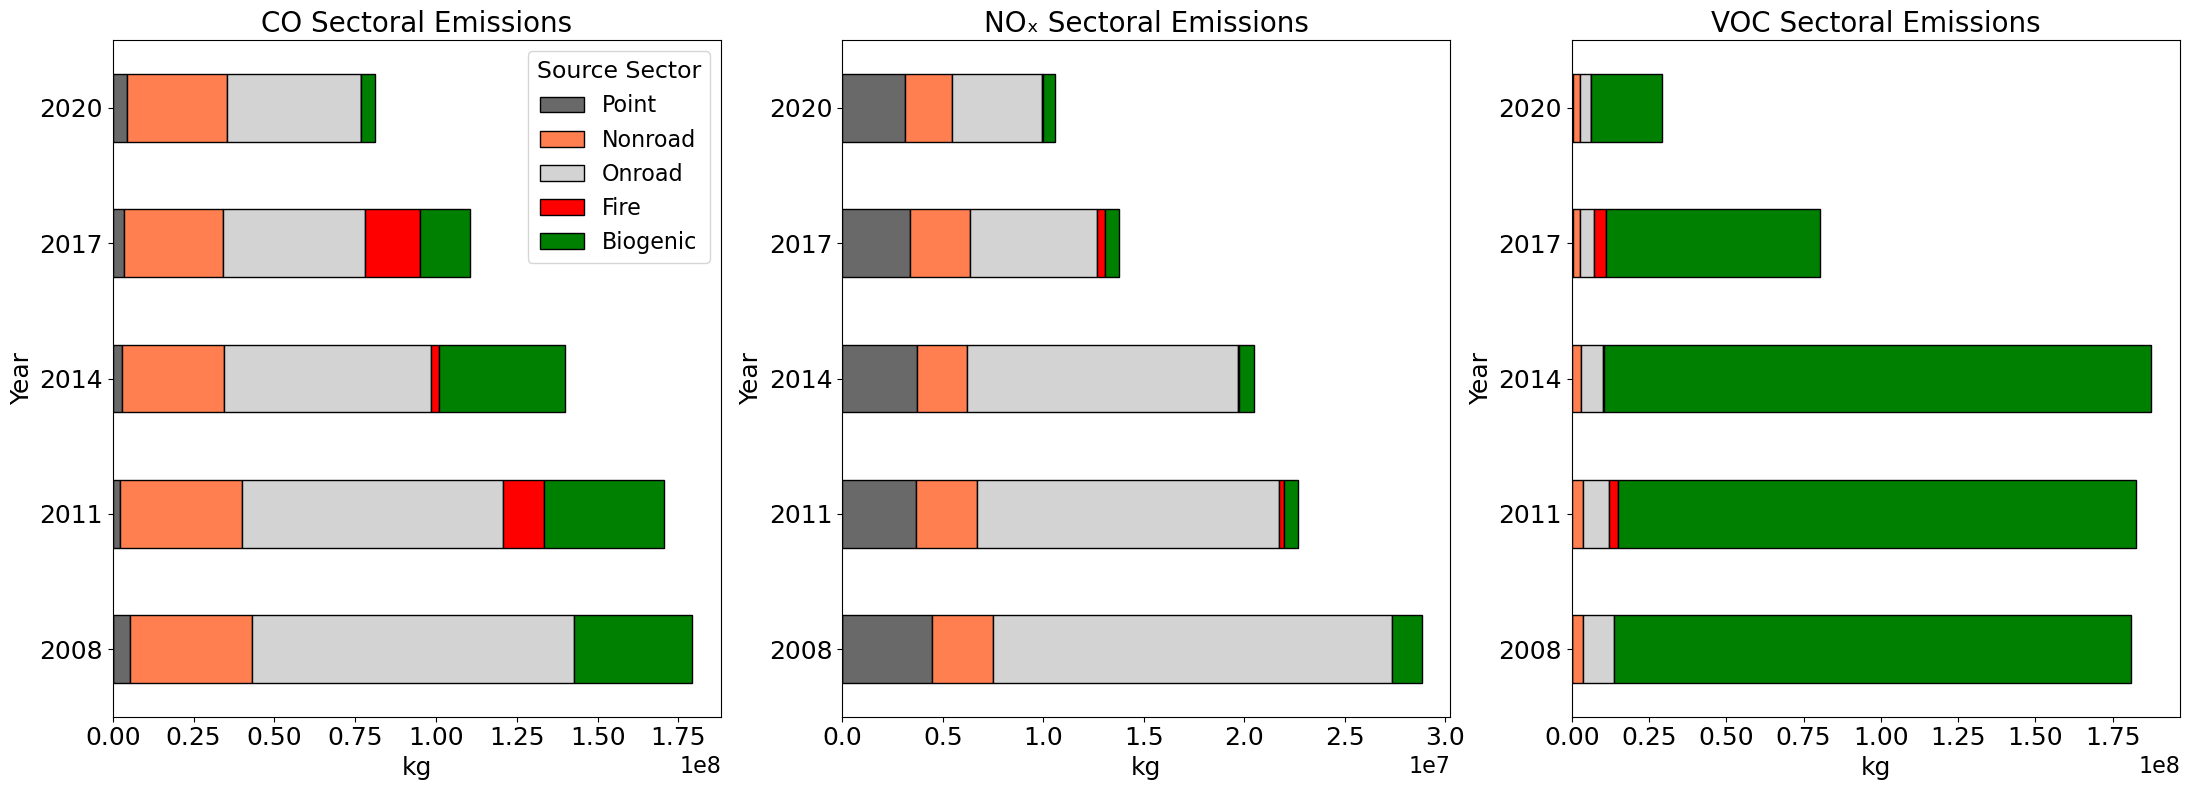

In [38]:
from matplotlib.ticker import ScalarFormatter

def prepare_sector_df(point, nonroad, onroad, fire, bio):
    return pd.DataFrame({
        'Point': point.set_index('year')['ton'] * 907.18474,
        'Nonroad': nonroad.set_index('year')['ton'] * 907.18474,
        'Onroad': onroad.set_index('year')['ton'] * 907.18474,
        'Fire': fire.set_index('year')['value']* 907.18474,
        'Biogenic': bio.set_index('year')['value'] * 907.18474
    })

# Prepare sector data for each pollutant
co_df = prepare_sector_df(df_point_CO, df_nonroad_CO, df_onroad_CO, df_fire_CO, Bio_CO)
nox_df = prepare_sector_df(df_point_NOx, df_nonroad_NOx, df_onroad_NOx, df_fire_NOx, Bio_NOx)
voc_df = prepare_sector_df(df_point_VOC, df_nonroad_VOC, df_onroad_VOC, df_fire_VOC, Bio_VOC)

# Plot configuration
fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharey=False)
pollutants = [('CO', co_df), ('NOₓ', nox_df), ('VOC', voc_df)]
colors = ['dimgray', 'coral', 'lightgray', 'red', 'g']

for i, (ax, (title, df)) in enumerate(zip(axes, pollutants)):
    df_sorted = df.sort_index(ascending=True)
    df_sorted.plot(kind='barh', stacked=True, ax=ax, color=colors, edgecolor='black', legend=(i == 0))
    ax.set_title(f"{title} Sectoral Emissions", fontsize=20)
    ax.set_xlabel("kg", fontsize=18)
    ax.set_ylabel("Year", fontsize=18)
    ax.tick_params(axis='both', which='both', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.tick_params(axis='x', labelsize=18)

    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.xaxis.get_offset_text().set_fontsize(16)  # Offset text fontsize (e.g. 1e8)

    if i == 0:
        ax.legend(title='Source Sector', fontsize=16, title_fontsize=17)
    else:
        ax.legend().set_visible(False)

plt.tight_layout()
plt.show()


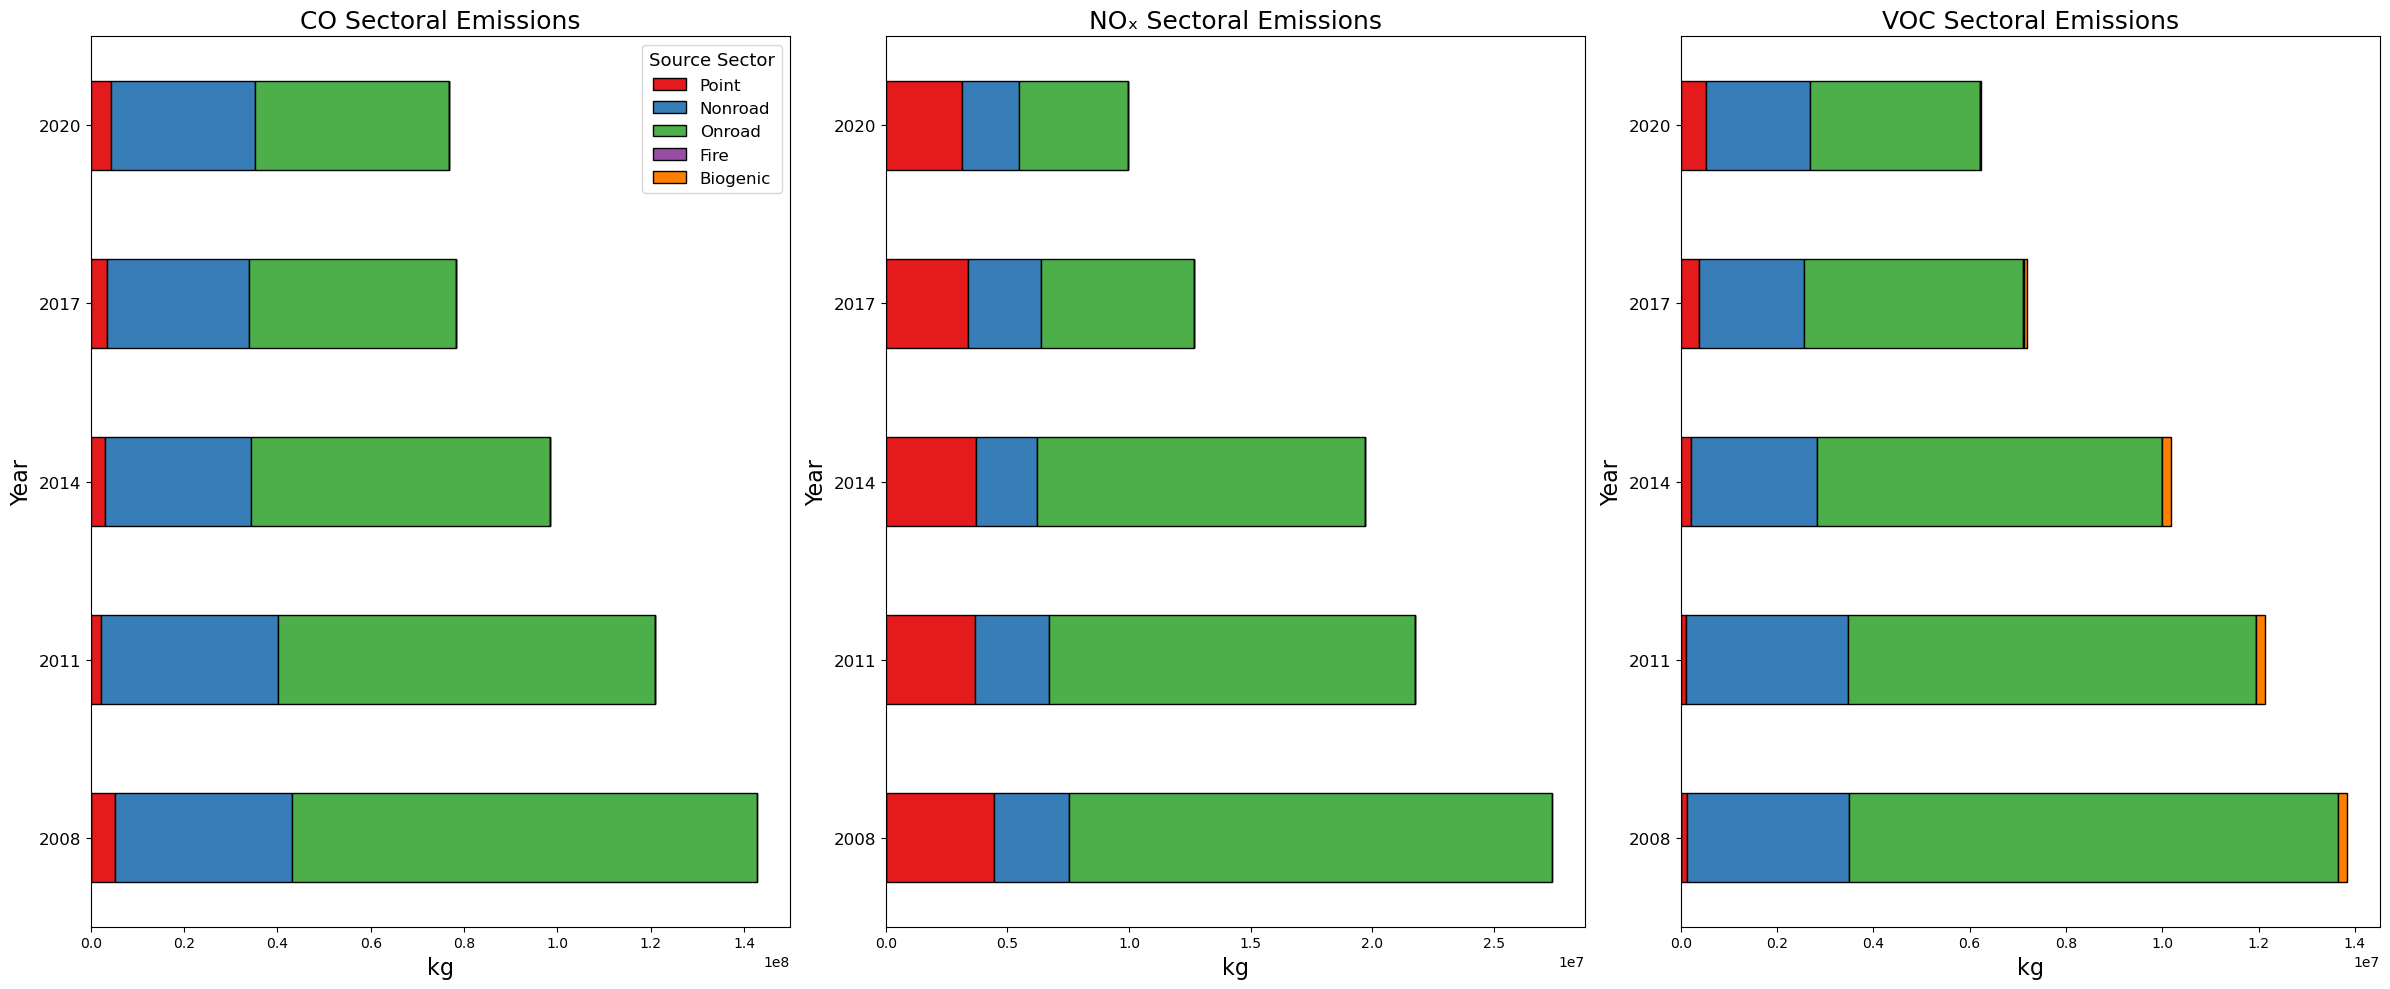

In [39]:


def prepare_sector_df(point, nonroad, onroad, fire, bio):
    return pd.DataFrame({
        'Point': point.set_index('year')['ton'] * 907.18474,
        'Nonroad': nonroad.set_index('year')['ton'] * 907.18474,
        'Onroad': onroad.set_index('year')['ton'] * 907.18474,
        'Fire': fire.set_index('year')['value'],
        'Biogenic': bio.set_index('year')['value']
    })

# Prepare sector data for each pollutant
co_df = prepare_sector_df(df_point_CO, df_nonroad_CO, df_onroad_CO, df_fire_CO, Bio_CO)
nox_df = prepare_sector_df(df_point_NOx, df_nonroad_NOx, df_onroad_NOx, df_fire_NOx, Bio_NOx)
voc_df = prepare_sector_df(df_point_VOC, df_nonroad_VOC, df_onroad_VOC, df_fire_VOC, Bio_VOC)

# Plot configuration
fig, axes = plt.subplots(1, 3, figsize=(24, 10), sharex=False)
pollutants = [('CO', co_df), ('NOₓ', nox_df), ('VOC', voc_df)]
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

for i, (ax, (title, df)) in enumerate(zip(axes, pollutants)):
    df_sorted = df.sort_index(ascending=True)
    df_sorted.plot(kind='barh', stacked=True, ax=ax, color=colors, edgecolor='black', legend=(i == 0))
    ax.set_title(f"{title} Sectoral Emissions", fontsize=18)
    ax.set_xlabel("kg", fontsize=16)
    ax.set_ylabel("Year", fontsize=16)
    ax.tick_params(axis='y', labelsize=12)

    if i == 0:
        ax.legend(title='Source Sector', fontsize=12, title_fontsize=13)
    else:
        ax.legend().set_visible(False)

plt.tight_layout()
plt.show()

